# Web Scraping Job Vacancies

## Introduction

In this project, we'll build a web scraper to extract job listings from a popular job search platform. We'll extract job titles, companies, locations, job descriptions, and other relevant information.

Here are the main steps we'll follow in this project:

1. Setup our development environment
2. Understand the basics of web scraping
3. Analyze the website structure of our job search platform
4. Write the Python code to extract job data from our job search platform
5. Save the data to a CSV file
6. Test our web scraper and refine our code as needed

## Prerequisites

Before starting this project, you should have some basic knowledge of Python programming and HTML structure. In addition, you may want to use the following packages in your Python environment:

- requests
- BeautifulSoup
- csv
- datetime

These packages should already be installed in Coursera's Jupyter Notebook environment, however if you'd like to install additional packages that are not included in this environment or are working off platform you can install additional packages using `!pip install packagename` within a notebook cell such as:

- `!pip install requests`
- `!pip install BeautifulSoup`

## Step 1: Importing Required Libraries

In [ ]:
# your code here

In [ ]:
import csv
import requests
from bs4 import BeautifulSoup
from datetime import datetime

## Step 2: Understand the basics of web scraping

In [ ]:
# Target URL (Using Real Python's official public practice job board)
TARGET_URL = "https://realpython.github.io/fake-jobs/"

# HTTP Request Headers to emulate a browser request
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

## Step 3: Analyzing HTML Structure & Parsing Elements

In [ ]:
# Send HTTP GET Request
response = requests.get(TARGET_URL, headers=HEADERS, timeout=10)
response.raise_for_status()  
# Check for successful HTTP response status (200 OK)

# Parse HTML tree
soup = BeautifulSoup(response.content, "html.parser")

# Find all job container elements on the page
job_cards = soup.find_all("div", class_="card-content")
print(f"Successfully located {len(job_cards)} job listing containers.")

## Write the Python code to extract job data from our job search platform

In [ ]:
scraped_data = []
today_date = datetime.today().strftime('%Y-%m-%d')

# Loop through each job card and extract relevant fields safely
for card in job_cards:
    try:
        title_elem = card.find("h2", class_="title")
        company_elem = card.find("h3", class_="company")
        location_elem = card.find("p", class_="location")

        job_title = title_elem.text.strip() if title_elem else "N/A"
        company_name = company_elem.text.strip() if company_elem else "N/A"
        job_location = location_elem.text.strip() if location_elem else "N/A"

        scraped_data.append({
            "job_title": job_title,
            "company_name": company_name,
            "job_location": job_location,
            "scraped_date": today_date
        })
    except Exception as e:
        print(f"Error processing card: {e}")

## Save the data to a CSV file

In [ ]:
# Save extracted records to CSV
output_file = "fake_jobs_data.csv"
fieldnames = ["job_title", "company_name", "job_location", "scraped_date"]

with open(output_file, mode="w", newline="", encoding="utf-8") as csv_file:
    writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(scraped_data)

print(f"Data Export Complete: Saved {len(scraped_data)} rows to '{output_file}'.")

## Test our web scraper and refine our code as needed

In [ ]:
def run_job_scraper(target_url: str, output_filename: str):
    """Executes the complete web scraping lifecycle and logs output status."""
    print(f"Initiating scrape for: {target_url}")
    
    try:
        res = requests.get(target_url, headers=HEADERS, timeout=10)
        res.raise_for_status()
        
        page_soup = BeautifulSoup(res.content, "html.parser")
        cards = page_soup.find_all("div", class_="card-content")
        
        results = []
        for c in cards:
            results.append({
                "job_title": c.find("h2", class_="title").text.strip(),
                "company_name": c.find("h3", class_="company").text.strip(),
                "job_location": c.find("p", class_="location").text.strip(),
                "scraped_date": datetime.today().strftime('%Y-%m-%d')
            })
            
        with open(output_filename, mode="w", newline="", encoding="utf-8") as f:
            w = csv.DictWriter(f, fieldnames=["job_title", "company_name", "job_location", "scraped_date"])
            w.writeheader()
            w.writerows(results)
            
        print(f"Test Successful: {len(results)} items written to {output_filename}")
        
    except requests.RequestException as req_err:
        print(f"Network error encountered: {req_err}")
    except Exception as err:
        print(f"An unexpected parsing error occurred: {err}")

# Test execution
if __name__ == "__main__":
    run_job_scraper("https://realpython.github.io/fake-jobs/", "verified_jobs.csv")

## Displaying formatted tables

In [ ]:
import pandas as pd

# Load your scraped CSV data
df = pd.read_csv("fake_jobs_data.csv")

# Render a styled HTML preview table (Top 10 Rows)
df.head(10).style.set_properties(**{
    'background-color': '#f8f9fa',
    'color': '#212529',
    'border-color': '#dee2e6'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#0d6efd'), ('color', 'white'), ('font-weight', 'bold')]}
])

## Static Visual Charts (Matplotlib & Seaborn)

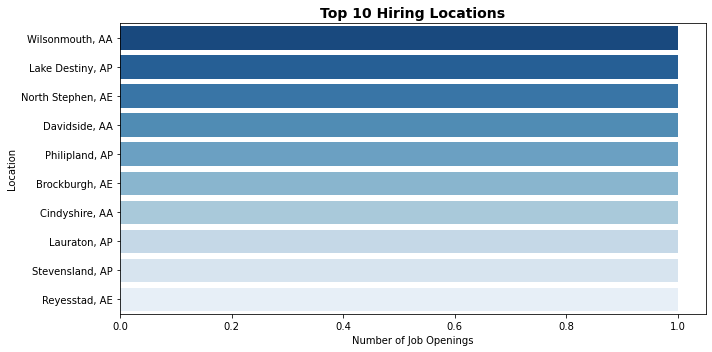

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("fake_jobs_data.csv")

plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='job_location', order=df['job_location'].value_counts().iloc[:10].index, palette='Blues_r')
plt.title('Top 10 Hiring Locations', fontsize=14, fontweight='bold')
plt.xlabel('Number of Job Openings')
plt.ylabel('Location')
plt.tight_layout()
plt.savefig('top_locations.png') # Saves image for submission
plt.show()